# Task 1 - Step 2: Controlled interventions on the common 224x224 image

Each intervention changes **one** visual factor while preserving the others as far as possible:

| Intervention | Changes | Preserves |
|---|---|---|
| Grayscale | chromatic information | luminance, edges, shape, texture |
| Hue rotation (+180 deg) | which colour each pixel has | luminance-ish structure, saturation, geometry |
| Translation (0/8/16/32 px, 4 directions) | absolute object position | content, local texture |
| Patch shuffle (4x4 grid) | global spatial arrangement | pixels, local evidence inside each 56x56 patch |

All transforms are applied to the **uint8 224x224 clean images** *before* any model normalisation and are saved to disk, so the same pixels are reused by all models.

In [1]:
# ---- Common header (identical in every Task 1 notebook) ----
import json, random, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Locate the task1/ folder no matter where Jupyter was launched from.
ROOT = Path.cwd()
if not (ROOT / "configs").exists() and (ROOT / "task1" / "configs").exists():
    ROOT = ROOT / "task1"

CFG = json.loads((ROOT / "configs" / "task1_config.json").read_text())
SEED = CFG["seed"]

# Small, git-tracked outputs -> results/.  Large tensors/weights/raw data -> cache/ and data/ (git-ignored).
RES = ROOT / "results"
CACHE = ROOT / "cache"
DATA = ROOT / "data"
for p in [RES / "subset", RES / "cue_conflicts", RES / "tables", RES / "figures",
          CACHE / "sets", CACHE / "features", CACHE / "heads", CACHE / "weights", DATA]:
    p.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def set_seed(seed=SEED):
    """Fix every RNG we use so reruns reproduce the same numbers."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed()
print("ROOT:", ROOT, "| device:", DEVICE, "| seed:", SEED)

ROOT: C:\Users\afifh\Desktop\ATML\PA1\task1 | device: cuda | seed: 6304


In [2]:
import torch.nn.functional as F
import torchvision.transforms.functional as TF

blob = torch.load(CACHE / "sets" / "clean.pt")
clean, labels = blob["images"], blob["labels"]
CLASSES = json.loads((RES / "subset" / "subset_ids.json").read_text())["classes"]
N = len(clean)
print("clean:", tuple(clean.shape), clean.dtype)

def save_set(name, images, extra=None):
    """Store an intervention as uint8 tensor aligned index-by-index with the clean subset."""
    assert images.dtype == torch.uint8 and images.shape == clean.shape, (images.dtype, images.shape)
    torch.save({"images": images, "labels": labels, **(extra or {})}, CACHE / "sets" / f"{name}.pt")
    print(f"saved set '{name}'")

clean: (500, 3, 224, 224) torch.uint8


## 2.1 Grayscale

`TF.rgb_to_grayscale(..., num_output_channels=3)` computes luminance `0.299R + 0.587G + 0.114B` and replicates it into 3 channels so the models still receive an RGB-shaped input. It removes colour but not shape or texture.

In [3]:
gray = torch.stack([TF.rgb_to_grayscale(im, num_output_channels=3) for im in clean])
save_set("grayscale", gray)

saved set 'grayscale'


## 2.2 Additional colour intervention: fixed hue rotation

`TF.adjust_hue(img, 0.5)` rotates hue by half the colour wheel (180 degrees), i.e. every colour becomes (roughly) its complement while saturation and value are preserved. Unlike grayscale, this *keeps* chromatic information but makes it **wrong** for the object (blue sky -> orange, green grass -> magenta). It therefore tests sensitivity to changing colour, rather than to its absence.

In [4]:
hue = torch.stack([TF.adjust_hue(im, CFG["color"]["hue_shift"]) for im in clean])
save_set("hue_rotate", hue)

saved set 'hue_rotate'


## 2.3 Translation with reflection padding

For displacement `d` in direction `(dx, dy)`: reflect-pad every side by `pad = max displacement`, then crop a 224x224 window shifted by `(-dx, -dy)`. The object therefore moves by `(+dx, +dy)` and the uncovered border is filled with a mirrored image (no black borders that could act as a cue). `d = 0` is the identity, so it is the clean set.

Directions: `right` (dx=+d), `left` (dx=-d), `down` (dy=+d), `up` (dy=-d).

In [5]:
DIR_VEC = {"right": (1, 0), "left": (-1, 0), "down": (0, 1), "up": (0, -1)}
PAD = max(CFG["translation"]["displacements"])

def translate(images_u8, dx, dy, pad=PAD, chunk=100):
    out = []
    for i in range(0, len(images_u8), chunk):
        x = images_u8[i:i + chunk].float()
        xp = F.pad(x, (pad, pad, pad, pad), mode="reflect")        # reflection padding
        H, W = x.shape[-2:]
        crop = xp[..., pad - dy: pad - dy + H, pad - dx: pad - dx + W]   # shifted crop
        out.append(crop.round().clamp(0, 255).to(torch.uint8))
    return torch.cat(out)

# Sanity check: zero shift == identity
assert torch.equal(translate(clean[:8], 0, 0), clean[:8])

for d in CFG["translation"]["displacements"]:
    for name in CFG["translation"]["directions"]:
        ux, uy = DIR_VEC[name]
        save_set(f"translate_{name}_{d}", translate(clean, ux * d, uy * d), {"dx": ux * d, "dy": uy * d})

saved set 'translate_right_8'


saved set 'translate_left_8'


saved set 'translate_down_8'


saved set 'translate_up_8'


saved set 'translate_right_16'


...

saved set 'translate_up_16'


saved set 'translate_right_32'


saved set 'translate_left_32'


saved set 'translate_down_32'


saved set 'translate_up_32'


## 2.4 Patch shuffle (4x4 grid, seed 6304)

Each image is cut into a 4x4 grid of 56x56-pixel patches and the 16 patches are permuted. The permutation is:

* different for every image (RNG seeded with `6304 + image_index`),
* guaranteed **non-identity** (re-drawn if it equals the identity),
* saved, so the exact shuffled images can be regenerated and the same shuffled images are reused for every model.

The pixels are unchanged; only their global arrangement is destroyed.

In [6]:
G = CFG["patch"]["grid"]
H = clean.shape[-1]
ps = H // G                                   # 56 px
assert ps * G == H

def patch_shuffle(img, perm):
    # [3,H,W] -> [G*G, 3, ps, ps] patches in row-major order
    p = img.unfold(1, ps, ps).unfold(2, ps, ps)            # [3,G,G,ps,ps]
    p = p.permute(1, 2, 0, 3, 4).reshape(G * G, 3, ps, ps)
    p = p[perm]                                            # reorder patches
    p = p.reshape(G, G, 3, ps, ps).permute(2, 0, 3, 1, 4).reshape(3, H, H)
    return p

perms = []
shuffled = []
for i in range(N):
    g = np.random.RandomState(SEED + i)
    perm = g.permutation(G * G)
    while np.array_equal(perm, np.arange(G * G)):          # never the identity permutation
        perm = g.permutation(G * G)
    perms.append(perm)
    shuffled.append(patch_shuffle(clean[i], torch.as_tensor(perm)))
shuffled = torch.stack(shuffled)

# Sanity checks: identity perm returns the original; pixel multiset per image preserved
assert torch.equal(patch_shuffle(clean[0], torch.arange(G * G)), clean[0])
assert torch.equal(clean[3].flatten().sort().values, shuffled[3].flatten().sort().values)
assert all(not np.array_equal(p, np.arange(G * G)) for p in perms)

save_set("patch_shuffle", shuffled, {"perms": torch.as_tensor(np.stack(perms))})
(RES / "subset" / "patch_permutations.json").write_text(json.dumps([p.tolist() for p in perms]))

saved set 'patch_shuffle'


28000

## 2.5 Visual check of every intervention

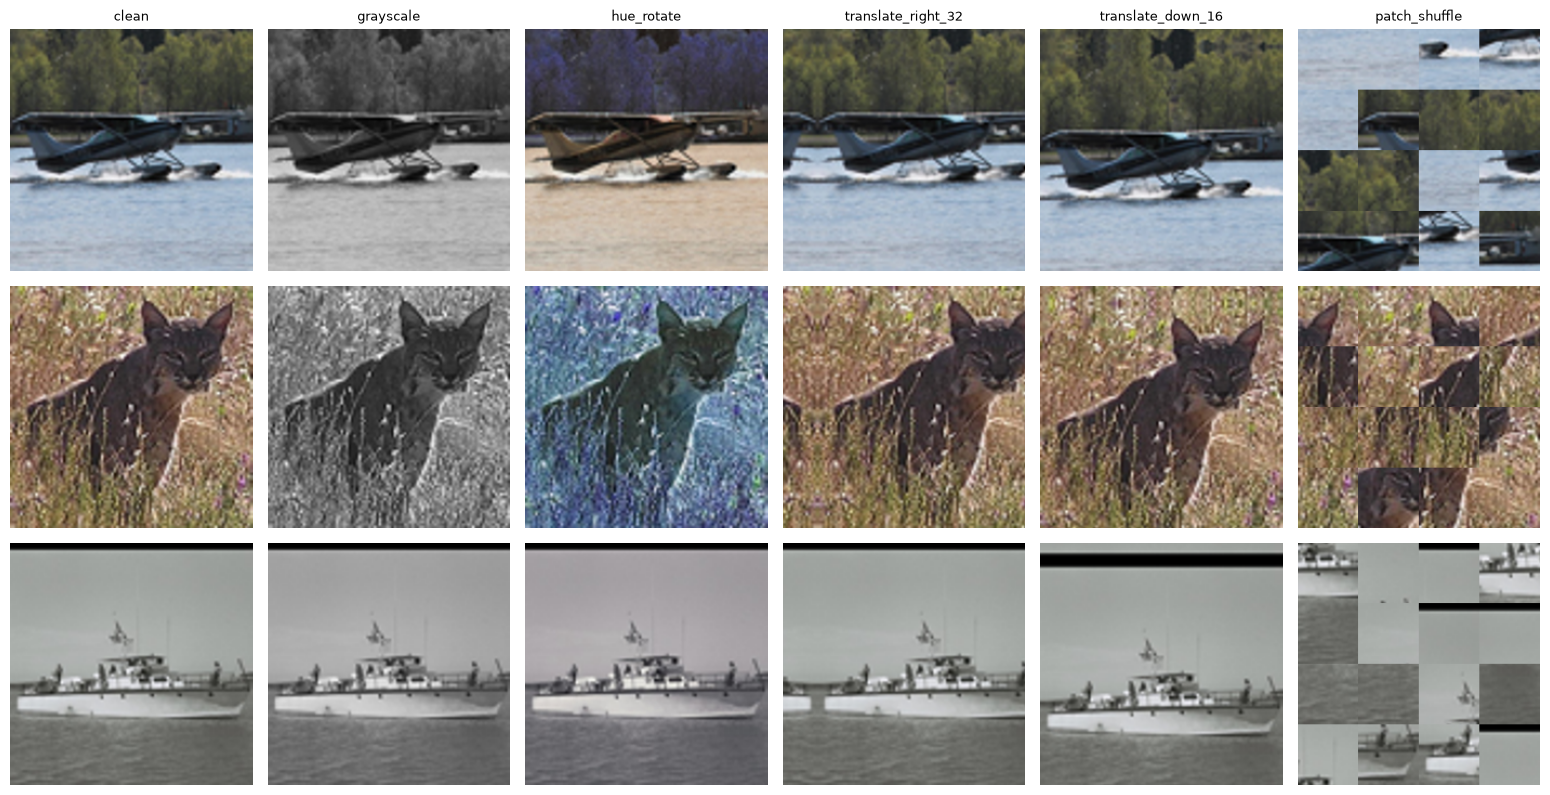

In [7]:
names = ["clean", "grayscale", "hue_rotate", "translate_right_32", "translate_down_16", "patch_shuffle"]
idxs = [int(np.where(labels.numpy() == c)[0][1]) for c in (0, 3, 8)]     # airplane, cat, ship
fig, axes = plt.subplots(len(idxs), len(names), figsize=(2.6 * len(names), 2.7 * len(idxs)))
for r, i in enumerate(idxs):
    for c, n in enumerate(names):
        im = clean if n == "clean" else torch.load(CACHE / "sets" / f"{n}.pt")["images"]
        axes[r, c].imshow(im[i].permute(1, 2, 0).numpy()); axes[r, c].axis("off")
        if r == 0: axes[r, c].set_title(n, fontsize=9)
plt.tight_layout(); plt.savefig(RES / "figures" / "transform_examples.png", dpi=120); plt.show()